# Customer Churn Prediction

## 1. Business Problem

Customer churn refers to customers discontinuing a company's services. 
The objective of this project is to analyze customer characteristics and 
service usage patterns, identify factors associated with churn, and build 
machine learning models to predict customers who are likely to churn.

The analysis uses the Telco Customer Churn dataset and compares Logistic 
Regression and Random Forest models for churn prediction.

## 2. Load Dataset

In [1]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Data Inspection

In [2]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nInfo:")
df.info()

Shape: (7043, 21)

Columns:
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   In

In [3]:
df['TotalCharges'].value_counts().head()

         11
20.2     11
19.75     9
20.05     8
19.9      8
Name: TotalCharges, dtype: int64

In [4]:
df['TotalCharges'].tail()

7038    1990.5
7039    7362.9
7040    346.45
7041     306.6
7042    6844.5
Name: TotalCharges, dtype: object

In [5]:
print("Blank TotalCharges:",(df['TotalCharges'].str.strip() == '').sum())

Blank TotalCharges: 11


In [6]:
df[df['TotalCharges'].str.strip() == ''][['customerID', 'tenure', 'MonthlyCharges', 'Churn']]

,customerID,tenure,MonthlyCharges,Churn
488,4472-LVYGI,0,52.55,No
753,3115-CZMZD,0,20.25,No
936,5709-LVOEQ,0,80.85,No
1082,4367-NUYAO,0,25.75,No
1340,1371-DWPAZ,0,56.05,No
3331,7644-OMVMY,0,19.85,No
3826,3213-VVOLG,0,25.35,No
4380,2520-SGTTA,0,20.00,No
5218,2923-ARZLG,0,19.70,No
6670,4075-WKNIU,0,73.35,No


## 4. Data Cleaning

The `TotalCharges` column is stored as a text/object column even though it represents a numerical value. Some customers with zero tenure have blank `TotalCharges` values. These blanks are replaced with `0` and the column is converted to a numeric data type.

In [7]:
df['TotalCharges'] = df['TotalCharges'].str.strip().replace('', '0')

In [8]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 5. Exploratory Data Analysis

The exploratory analysis examines the distribution of churn and investigates relationships between customer characteristics, service usage, contract type, tenure, charges, and churn.

In [10]:
df['Churn'].value_counts()

No     5174
Yes    1869
Name: Churn, dtype: int64

In [11]:
df['Churn'].value_counts(normalize=True) * 100

No     73.463013
Yes    26.536987
Name: Churn, dtype: float64

In [12]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [13]:
contract_churn = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack() * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [14]:
import matplotlib.pyplot as plt

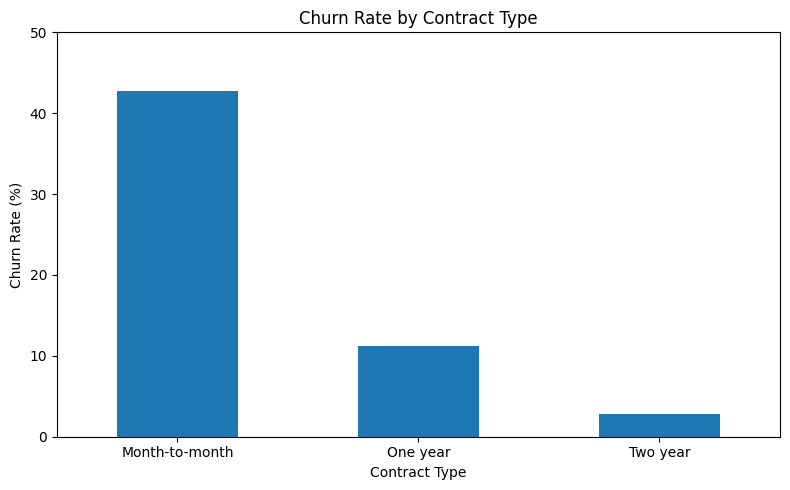

In [15]:
contract_churn_rate = contract_churn['Yes']

contract_churn_rate.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.ylim(0, 50)
plt.tight_layout()
plt.show()

**Key insight:** Month-to-month customers have the highest churn rate at 42.71%, compared with 11.27% for one-year contracts and 2.83% for two-year contracts. This indicates that contract type is strongly associated with customer retention in this dataset.

In [16]:
df.groupby('Churn')['MonthlyCharges'].mean()

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

In [17]:
df.groupby('Contract')['tenure'].mean()

Contract
Month-to-month    18.036645
One year          42.044807
Two year          56.735103
Name: tenure, dtype: float64

In [18]:
df.groupby('Contract')['MonthlyCharges'].mean()

Contract
Month-to-month    66.398490
One year          65.048608
Two year          60.770413
Name: MonthlyCharges, dtype: float64

In [19]:
df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=[-1, 12, 24, 48, 72],
    labels=['0-12 months', '13-24 months', '25-48 months', '49-72 months']
)

In [20]:
df.groupby('TenureGroup')['Churn'].value_counts(normalize=True).unstack() * 100

Churn,No,Yes
TenureGroup,,
0-12 months,52.561757,47.438243
13-24 months,71.289062,28.710938
25-48 months,79.611041,20.388959
49-72 months,90.486824,9.513176


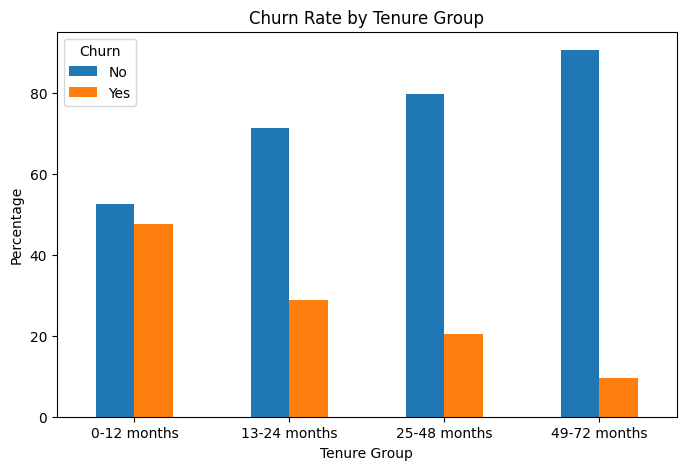

In [21]:
tenure_churn = (
    df.groupby('TenureGroup')['Churn']
      .value_counts(normalize=True)
      .unstack()
      * 100
)

tenure_churn.plot(kind='bar', figsize=(8, 5))

plt.title('Churn Rate by Tenure Group')
plt.xlabel('Tenure Group')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.show()

In [22]:
contract_tenure_churn = (
    df.groupby(['Contract', 'TenureGroup'])['Churn']
      .value_counts(normalize=True)
      .unstack()
      * 100
)

contract_tenure_churn

Churn                                No        Yes
Contract       TenureGroup                        
Month-to-month 0-12 months    48.645938  51.354062
               13-24 months   62.279512  37.720488
               25-48 months   67.082294  32.917706
               49-72 months   73.976608  26.023392
One year       0-12 months    89.516129  10.483871
               13-24 months   91.878173   8.121827
               25-48 months   89.382239  10.617761
               49-72 months   87.066246  12.933754
Two year       0-12 months   100.000000        NaN
               13-24 months  100.000000        NaN
               25-48 months   97.810219   2.189781
               49-72 months   96.674584   3.325416

In [23]:
segment_counts = (
    df.groupby(['Contract', 'TenureGroup'], observed=True)
      .size()
      .reset_index(name='CustomerCount')
)

segment_counts

,Contract,TenureGroup,CustomerCount
0,Month-to-month,0-12 months,1994
1,Month-to-month,13-24 months,737
2,Month-to-month,25-48 months,802
3,Month-to-month,49-72 months,342
4,One year,0-12 months,124
5,One year,13-24 months,197
6,One year,25-48 months,518
7,One year,49-72 months,634
8,Two year,0-12 months,68
9,Two year,13-24 months,90


In [24]:
contract_tenure_churn_rate = contract_tenure_churn['Yes'].unstack()

contract_tenure_churn_rate

TenureGroup,0-12 months,13-24 months,25-48 months,49-72 months
Contract,,,,
Month-to-month,51.354062,37.720488,32.917706,26.023392
One year,10.483871,8.121827,10.617761,12.933754
Two year,NaN,NaN,2.189781,3.325416


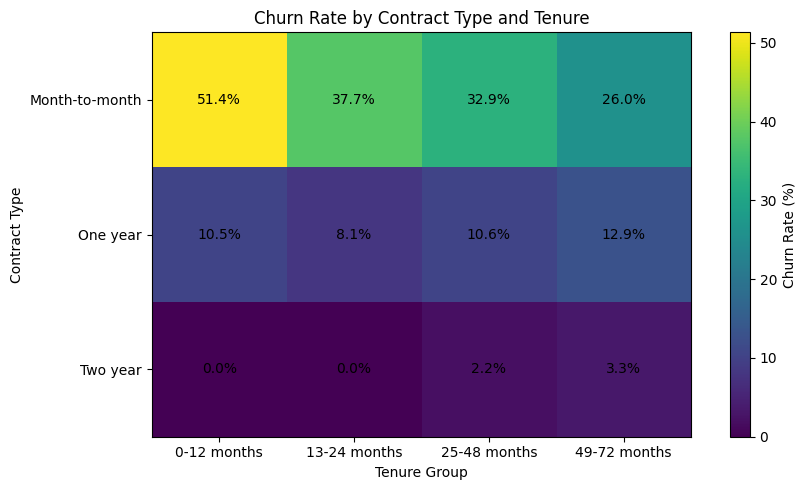

In [25]:
import matplotlib.pyplot as plt
import numpy as np

heatmap_data = contract_tenure_churn_rate.fillna(0)

fig, ax = plt.subplots(figsize=(9, 5))

im = ax.imshow(heatmap_data.values)

ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns)

ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)

for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        ax.text(
            j, i,
            f"{heatmap_data.iloc[i, j]:.1f}%",
            ha="center",
            va="center"
        )

ax.set_title('Churn Rate by Contract Type and Tenure')
ax.set_xlabel('Tenure Group')
ax.set_ylabel('Contract Type')

plt.colorbar(im, label='Churn Rate (%)')
plt.tight_layout()
plt.show()

**Key insight:** Month-to-month customers in their first 12 months have the highest observed churn rate at 51.35%. Churn among month-to-month customers decreases as tenure increases, while customers on longer-term contracts consistently show much lower churn. This suggests that early-tenure, month-to-month customers should be a primary target for retention efforts.

In [26]:
internet_churn = (
    df.groupby('InternetService')['Churn']
      .value_counts(normalize=True)
      .unstack()
      * 100
)

internet_churn

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


In [27]:
df['InternetService'].value_counts()

Fiber optic    3096
DSL            2421
No             1526
Name: InternetService, dtype: int64

In [28]:
df.groupby('InternetService')['MonthlyCharges'].mean()

InternetService
DSL            58.102169
Fiber optic    91.500129
No             21.079194
Name: MonthlyCharges, dtype: float64

In [29]:
internet_contract = pd.crosstab(
    df['InternetService'],
    df['Contract'],
    normalize='index'
) * 100

internet_contract

Contract,Month-to-month,One year,Two year
InternetService,,,
DSL,50.516316,23.543990,25.939694
Fiber optic,68.733850,17.409561,13.856589
No,34.338139,23.853211,41.808650


In [30]:
internet_contract_churn = (
    df.groupby(['InternetService', 'Contract'])['Churn']
      .value_counts(normalize=True)
      .unstack()
      * 100
)

internet_contract_churn

Churn                                  No        Yes
InternetService Contract                            
DSL             Month-to-month  67.784137  32.215863
                One year        90.701754   9.298246
                Two year        98.089172   1.910828
Fiber optic     Month-to-month  45.394737  54.605263
                One year        80.705009  19.294991
                Two year        92.773893   7.226107
No              Month-to-month  81.106870  18.893130
                One year        97.527473   2.472527
                Two year        99.216301   0.783699

**Key insight:** Fiber-optic customers on month-to-month contracts have the highest observed churn rate at 54.61%. Longer-term contracts show substantially lower churn across all internet service types. This suggests that retention efforts should prioritize month-to-month fiber-optic customers, while also investigating service quality and customer experience for this segment.

In [31]:
payment_churn = (
    df.groupby('PaymentMethod')['Churn']
      .value_counts(normalize=True)
      .unstack()
      * 100
)

payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


In [32]:
payment_contract = pd.crosstab(
    df['PaymentMethod'],
    df['Contract'],
    normalize='index'
) * 100

payment_contract

Contract,Month-to-month,One year,Two year
PaymentMethod,,,
Bank transfer (automatic),38.147668,25.323834,36.528497
Credit card (automatic),35.676741,26.149803,38.173456
Electronic check,78.224101,14.672304,7.103594
Mailed check,55.397022,20.905707,23.697270


In [33]:
payment_contract_churn = (
    df.groupby(['PaymentMethod', 'Contract'])['Churn']
      .value_counts(normalize=True)
      .unstack()
      * 100
)

payment_contract_churn

Churn                                            No        Yes
PaymentMethod             Contract                            
Bank transfer (automatic) Month-to-month  65.874363  34.125637
                          One year        90.281330   9.718670
                          Two year        96.631206   3.368794
Credit card (automatic)   Month-to-month  67.219153  32.780847
                          One year        89.698492  10.301508
                          Two year        97.762478   2.237522
Electronic check          Month-to-month  46.270270  53.729730
                          One year        81.556196  18.443804
                          Two year        92.261905   7.738095
Mailed check              Month-to-month  68.421053  31.578947
                          One year        93.175074   6.824926
                          Two year        99.214660   0.785340

**Key insight:** Month-to-month customers using electronic checks have the highest observed churn rate at 53.73%. Month-to-month customers using other payment methods also show elevated churn, but at lower levels. This suggests that electronic-check, month-to-month customers should be prioritized for retention outreach and encouraged to consider alternative payment methods.

## 6. Data Preprocessing for Machine Learning

The target variable is converted into binary values, while the customer identifier and exploratory tenure grouping are excluded from the model features. Categorical variables are then converted into numerical dummy variables before splitting the data into training and testing sets.

In [34]:
y = df['Churn'].map({'No': 0, 'Yes': 1})

y.value_counts()

0    5174
1    1869
Name: Churn, dtype: int64

In [35]:
X = df.drop(columns=['Churn', 'customerID', 'TenureGroup'])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 19)
y shape: (7043,)


In [36]:
X = pd.get_dummies(X, drop_first=True)

print("X shape after encoding:", X.shape)
X.head()

X shape after encoding: (7043, 30)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,1,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,1,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,1,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,1,0


In [37]:
from sklearn.model_selection import train_test_split

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5634, 30)
X_test: (1409, 30)
y_train: (5634,)
y_test: (1409,)


In [39]:
print("Training churn distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting churn distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training churn distribution:
0    73.464679
1    26.535321
Name: Churn, dtype: float64

Testing churn distribution:
0    73.456352
1    26.543648
Name: Churn, dtype: float64


## 7. Model Training

In [40]:
from sklearn.linear_model import LogisticRegression

In [41]:
model = LogisticRegression(max_iter=1000)

In [42]:
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [43]:
from sklearn.ensemble import RandomForestClassifier

In [44]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [45]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## 8. Model Evaluation

The trained models are evaluated using accuracy, precision, recall, and F1 score. Since churn prediction is a binary classification problem, these metrics help assess both overall prediction performance and the model's ability to identify customers who actually churn.

In [46]:
y_pred = model.predict(X_test)

print(y_pred[:20])

[0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0]


In [47]:
y_prob = model.predict_proba(X_test)

print(y_prob[:5])

[[0.9494462  0.0505538 ]
 [0.32172896 0.67827104]
 [0.93887623 0.06112377]
 [0.59950064 0.40049936]
 [0.9794906  0.0205094 ]]


In [48]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.801277501774308
Precision: 0.6459627329192547
Recall   : 0.5561497326203209
F1 Score : 0.5977011494252874


In [49]:
rf_pred = rf_model.predict(X_test)

print(rf_pred[:20])

[0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0]


In [50]:
print("Random Forest")
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))

Random Forest
Accuracy : 0.7849538679914834
Precision: 0.6179401993355482
Recall   : 0.49732620320855614
F1 Score : 0.5511111111111111


### Model Comparison

Both models are evaluated using accuracy, precision, recall, and F1 score. Since the objective is to identify customers who are likely to churn, recall is particularly important because false negatives represent customers who actually churned but were not identified by the model.

In [51]:
model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_pred)
    ],
    'Precision': [
        precision_score(y_test, y_pred),
        precision_score(y_test, rf_pred)
    ],
    'Recall': [
        recall_score(y_test, y_pred),
        recall_score(y_test, rf_pred)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred),
        f1_score(y_test, rf_pred)
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.801278,0.645963,0.556150,0.597701
1,Random Forest,0.784954,0.617940,0.497326,0.551111


### Confusion Matrix

The confusion matrix provides a detailed view of the Logistic Regression predictions by showing true negatives, false positives, false negatives, and true positives.

In [52]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[921 114]
 [166 208]]


### Threshold Analysis

The default classification threshold of 0.50 was compared with a lower threshold of 0.30. Lowering the threshold makes the model more sensitive to potential churners, which can reduce false negatives but may increase false positives.

In [53]:
y_pred_30 = (y_prob[:, 1] >= 0.30).astype(int)

print(y_pred_30[:20])

[0 1 0 1 0 1 1 0 0 1 0 0 0 1 0 0 0 1 0 0]


In [54]:
print("Precision:", precision_score(y_test, y_pred_30))
print("Recall   :", recall_score(y_test, y_pred_30))

Precision: 0.5242537313432836
Recall   : 0.7513368983957219


In [55]:
cm_30 = confusion_matrix(y_test, y_pred_30)

print(cm_30)

[[780 255]
 [ 93 281]]


**Interpretation:** Lowering the threshold from 0.50 to 0.30 increased recall from 55.61% to 75.13% and reduced false negatives from 166 to 93. However, precision decreased from 64.60% to 52.42% and false positives increased. Therefore, the final threshold should be selected based on the relative business cost of missing a potential churner versus unnecessarily targeting a customer who would have stayed.

### Feature Interpretation

In [56]:
coefficient_table = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

coefficient_table['Abs_Coefficient'] = coefficient_table['Coefficient'].abs()

coefficient_table = coefficient_table.sort_values(
    by='Abs_Coefficient',
    ascending=False
)

coefficient_table.head(10)

,Feature,Coefficient,Abs_Coefficient
25,Contract_Two year,-1.246369,1.246369
10,InternetService_Fiber optic,0.747628,0.747628
24,Contract_One year,-0.669666,0.669666
7,PhoneService_Yes,-0.500567,0.500567
13,OnlineSecurity_Yes,-0.428495,0.428495
28,PaymentMethod_Electronic check,0.392645,0.392645
19,TechSupport_Yes,-0.381465,0.381465
26,PaperlessBilling_Yes,0.377314,0.377314
9,MultipleLines_Yes,0.271313,0.271313
6,Dependents_Yes,-0.229232,0.229232


**Interpretation:** In Logistic Regression, positive coefficients indicate an association with higher predicted churn probability, while negative coefficients indicate an association with lower predicted churn probability. The strongest negative coefficient is associated with two-year contracts, while fiber-optic internet service has the strongest positive coefficient among the displayed features. These coefficients describe associations learned by the model and should not be interpreted as causal relationships.

## 9. Model Selection and Business Recommendations

Based on the evaluation results, Logistic Regression was selected as the preferred model because it achieved higher accuracy, precision, recall, and F1 score than Random Forest on the test dataset.

The model can be used to identify customers with a higher likelihood of churn and help prioritize retention efforts.

In [57]:
model_comparison.round(3)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.801,0.646,0.556,0.598
1,Random Forest,0.785,0.618,0.497,0.551


### Business Recommendations

Based on the exploratory analysis and model findings, the following customer segments should receive focused retention efforts:

1. **Early-tenure customers:** Customers in their first 12 months show substantially higher churn. Introduce onboarding programs, early engagement campaigns, and targeted retention offers.

2. **Month-to-month customers:** Month-to-month customers have much higher churn than customers on longer-term contracts. Offer appropriate incentives for customers to consider longer-term plans.

3. **Month-to-month + early-tenure customers:** This is the highest-risk tenure/contract segment, with approximately 51.35% observed churn. Prioritize this segment for proactive retention campaigns.

4. **Fiber-optic + month-to-month customers:** This segment has approximately 54.61% observed churn. Prioritize these customers for retention outreach and investigate service quality and customer-experience issues.

5. **Electronic check + month-to-month customers:** This segment has approximately 53.73% observed churn. Encourage alternative payment methods and investigate whether payment experience or other characteristics of this segment contribute to the elevated churn.

6. **Consider a lower prediction threshold when the cost of missed churn is high:** A 0.30 threshold increased recall from 55.61% to 75.13% and reduced false negatives from 166 to 93, although precision decreased from 64.60% to 52.42%. The final threshold should therefore be selected according to the business cost of missing a potential churner versus contacting a customer who would have stayed.

## 10. Project Conclusion

This project analyzed customer churn using the Telco Customer Churn dataset and developed machine learning models to identify customers at higher risk of leaving the company.

The exploratory analysis showed that churn is particularly concentrated among month-to-month customers, early-tenure customers, fiber-optic customers, and electronic-check users. Combining these characteristics revealed several high-risk customer segments that can be targeted with proactive retention strategies.

Two classification models were evaluated: Logistic Regression and Random Forest. Logistic Regression performed better across accuracy, precision, recall, and F1 score, achieving an accuracy of approximately 80.13% and an F1 score of 59.77% on the test set.

A threshold analysis also showed that lowering the classification threshold from 0.50 to 0.30 increased recall from 55.61% to 75.13%, reducing false negatives from 166 to 93. This demonstrates how model predictions can be adjusted according to business priorities, particularly when identifying potential churners is more important than minimizing unnecessary retention outreach.

Overall, the analysis demonstrates how customer data and machine learning can be used not only to predict churn, but also to identify actionable customer segments and support data-driven retention decisions.

### Future Improvements

The project can be further improved by:

- Hyperparameter tuning for Logistic Regression and Random Forest.
- Testing additional classification algorithms such as Gradient Boosting or XGBoost.
- Using cross-validation for more robust model evaluation.
- Applying techniques to address class imbalance if required.
- Performing systematic threshold optimization based on business costs.
- Using explainability techniques such as SHAP to provide more detailed customer-level explanations.
- Deploying the final model through an API or dashboard for practical business use.